# Fire table from FIRMS detections
Turn the five yearly detection files into one row per fire, with an ignition point and a weight.
These ignitions are the demand points for the station-placement optimization.

Each year is processed separately: fires do not cross years. All dates and times are UTC.
Output: `data/processed/ignitions.parquet`.

## Config

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import Transformer
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from IPython.display import display

folder = Path.cwd().resolve()
REPO_ROOT = next((p for p in (folder, *folder.parents) if (p / "CLAUDE.md").is_file()), None)
if REPO_ROOT is None:
    raise RuntimeError("Launch from inside the repository.")
sys.path.insert(0, str(REPO_ROOT / "notebooks"))
from bc_geo import load_bc_boundary

YEARS = [2019, 2020, 2021, 2022, 2023]
TRAIN_YEARS = [2019, 2020, 2021, 2022]  # 2023 is the test year
FIRMS_DIR = REPO_ROOT / "data" / "processed" / "firms"
OUTPUT_PATH = REPO_ROOT / "data" / "processed" / "ignitions.parquet"
META_PATH = REPO_ROOT / "data" / "processed" / "ignitions_meta.json"

CELL_M = 375                     # thinning grid, about one VIIRS pixel
LINK_KM, LINK_DAYS = 3.0, 5      # two detections this close belong to the same fire
EARLY_HOURS = 48                 # window used for the size weight
ACTIVE_DAYS_CAP = 14
# Static heat sources: small fires that keep recurring at the same spot.
STATIC_MAX_EXTENT_KM, STATIC_MAX_CELLS_48H = 1, 2   # what counts as a small fire
STATIC_RADIUS_KM = 1                                # neighbourhood searched around each small fire
STATIC_MIN_FIRES, STATIC_MIN_YEARS = 8, 3           # small fires (incl. itself) and distinct years needed
WEIGHT_CAP_PERCENTILE = 95
SENSITIVITY = [(1.0, 2), (1.5, 3), (3.0, 5)]

EXPECTED_COLUMNS = ["latitude", "longitude", "bright_ti4", "scan", "track", "acq_date", "acq_time",
                    "satellite", "instrument", "confidence", "version", "bright_ti5", "frp", "daynight",
                    "type", "source", "acq_datetime", "local_time"]

## 1. Load and check
Confirm the 18 columns, then keep only vegetation fires. FIRMS `type` is 0 for presumed vegetation fire,
1 for active volcano, 2 for other static land source and 3 for offshore.

In [2]:
detections = {}
rows = []
for year in YEARS:
    frame = pd.read_csv(FIRMS_DIR / f"firms_bc_{year}.csv", low_memory=False)
    if list(frame.columns) != EXPECTED_COLUMNS:
        raise ValueError(f"{year}: unexpected columns {list(frame.columns)}")
    frame["acq_datetime"] = pd.to_datetime(frame["acq_datetime"], utc=True)
    counts = frame["type"].value_counts()
    rows.append({"year": year, "rows": len(frame),
                 **{f"type_{value}": int(counts.get(value, 0)) for value in (0, 1, 2, 3)},
                 "removed": int((frame["type"] != 0).sum())})
    detections[year] = frame[frame["type"] == 0].reset_index(drop=True)
print("All files have the expected 18 columns. Detections per type, and rows removed (type != 0):")
display(pd.DataFrame(rows).set_index("year"))

All files have the expected 18 columns. Detections per type, and rows removed (type != 0):


,rows,type_0,type_1,type_2,type_3,removed
year,,,,,,
2019,11344,11185,0,128,31,159
2020,6800,6605,0,183,12,195
2021,128711,128131,0,141,439,580
2022,27187,26930,0,182,75,257
2023,367254,365657,0,215,1382,1597


## 2. Thin
Project to BC Albers (EPSG:3005). Keep one detection per 375 m grid cell per UTC date: the one with the
highest FRP. `n_raw` keeps the original number of detections in that cell and date.

In [3]:
to_albers = Transformer.from_crs("EPSG:4326", "EPSG:3005", always_xy=True)


def thin(frame):
    frame = frame.copy()
    frame["x"], frame["y"] = to_albers.transform(frame["longitude"].to_numpy(), frame["latitude"].to_numpy())
    frame["cell_x"] = np.floor(frame["x"] / CELL_M).astype("int64")
    frame["cell_y"] = np.floor(frame["y"] / CELL_M).astype("int64")
    frame["date"] = frame["acq_datetime"].dt.tz_localize(None).dt.normalize()
    keys = ["cell_x", "cell_y", "date"]
    frame["n_raw"] = frame.groupby(keys)["frp"].transform("size")
    kept = frame.sort_values("frp", ascending=False, kind="stable").drop_duplicates(keys)
    return kept.sort_values("acq_datetime", kind="stable").reset_index(drop=True)


thinned = {year: thin(detections[year]) for year in YEARS}
display(pd.DataFrame({"before": {year: len(detections[year]) for year in YEARS},
                      "after": {year: len(thinned[year]) for year in YEARS}})
        .assign(kept_pct=lambda t: (100 * t["after"] / t["before"]).round(1)).rename_axis("year"))

,before,after,kept_pct
year,,,
2019,11185,9204,82.3
2020,6605,5501,83.3
2021,128131,90744,70.8
2022,26930,20289,75.3
2023,365657,257180,70.3


## 3. Cluster into fires
Two detections belong to the same fire if they are within 3 km and 5 days (120 hours) of each other.
A fire is a connected group of such links, so a fire can grow far and last long through a chain of
detections. `cKDTree.query_pairs` finds the spatial pairs, the time filter drops pairs too far apart
in time, and `connected_components` labels the fires.

Why 3 km / 5 days: a tighter 1.5 km / 3 day rule fragments large fires in big years (the 2023 fire count
roughly doubles), and the fragments would add false demand near big fires. Five days matches the linking
threshold used by NASA's FEDS fire-tracking system. The sensitivity table in section 7 shows all three settings.

In [4]:
def cluster(points, link_km, link_days):
    """Return (fire label per detection, spatial pair count, linked pair count)."""
    xy = points[["x", "y"]].to_numpy()
    days = (points["acq_datetime"] - points["acq_datetime"].min()).dt.total_seconds().to_numpy() / 86400
    pairs = cKDTree(xy).query_pairs(link_km * 1000, output_type="ndarray")
    linked = pairs[np.abs(days[pairs[:, 0]] - days[pairs[:, 1]]) <= link_days]
    graph = coo_matrix((np.ones(len(linked), dtype=bool), (linked[:, 0], linked[:, 1])),
                       shape=(len(points), len(points)))
    labels = connected_components(graph, directed=False)[1]
    return labels, len(pairs), len(linked)


rows = []
for year in YEARS:
    thinned[year]["fire"], spatial_pairs, linked_pairs = cluster(thinned[year], LINK_KM, LINK_DAYS)
    rows.append({"year": year, "detections": len(thinned[year]), "spatial_pairs": spatial_pairs,
                 "linked_pairs": linked_pairs, "fires": thinned[year]["fire"].nunique()})
display(pd.DataFrame(rows).set_index("year"))

,detections,spatial_pairs,linked_pairs,fires
year,,,,
2019,9204,176922,152723,1421
2020,5501,196793,113964,954
2021,90744,10183457,6604808,1631
2022,20289,1920283,1015243,815
2023,257180,30760754,18496762,2406


## 4. One row per fire
- `ignition_time_utc`: earliest detection. `lat`, `lon`: mean position of the detections on the ignition date.
- `active_days`: first to last date, inclusive. `active_days_capped`: at most 14.
- `n_detections`: original detection count, before thinning.
- `n_cells_48h`: distinct 375 m cells detected in the first 48 hours. `frp_sum_48h`: FRP summed over the
  thinned detections in those 48 hours (the strongest detection per cell per date).
- `extent_km`: diagonal of the fire's bounding box over its whole life.
- `source`: satellite product of the first detection.

In [5]:
def fire_table(points, year):
    fires = points.groupby("fire")
    ignition = fires["acq_datetime"].transform("min")
    on_first_date = points[points["date"] == fires["date"].transform("min")].groupby("fire")
    early = points[points["acq_datetime"] < ignition + pd.Timedelta(hours=EARLY_HOURS)]
    first = points.drop_duplicates("fire").set_index("fire")  # points are sorted by time

    table = pd.DataFrame({
        "ignition_time_utc": fires["acq_datetime"].min(),
        "lat": on_first_date["latitude"].mean(),
        "lon": on_first_date["longitude"].mean(),
        "first_date": fires["date"].min(),
        "last_date": fires["date"].max(),
        "n_detections": fires["n_raw"].sum(),
        "n_cells_48h": early.drop_duplicates(["fire", "cell_x", "cell_y"]).groupby("fire").size(),
        "frp_sum_48h": early.groupby("fire")["frp"].sum(),
        "extent_km": np.hypot(fires["x"].max() - fires["x"].min(), fires["y"].max() - fires["y"].min()) / 1000,
        "source": first["source"],
    })
    table["active_days"] = (table["last_date"] - table["first_date"]).dt.days + 1
    table["active_days_capped"] = table["active_days"].clip(upper=ACTIVE_DAYS_CAP)
    table = table.sort_values(["ignition_time_utc", "lat", "lon"]).reset_index(drop=True)
    table["year"] = year
    table["fire_id"] = [f"{year}-{number:05d}" for number in range(1, len(table) + 1)]
    return table


ignitions = pd.concat([fire_table(thinned[year], year) for year in YEARS], ignore_index=True)
ignitions = ignitions[["fire_id", "year", "ignition_time_utc", "lat", "lon", "first_date", "last_date",
                       "active_days", "active_days_capped", "n_detections", "n_cells_48h", "frp_sum_48h",
                       "extent_km", "source"]]
print(f"{len(ignitions):,} fires")
display(ignitions.head())

7,227 fires


,fire_id,year,ignition_time_utc,lat,lon,first_date,last_date,active_days,active_days_capped,n_detections,n_cells_48h,frp_sum_48h,extent_km,source
0,2019-00001,2019,2019-05-01 10:41:00+00:00,54.01561,-128.687033,2019-05-01,2019-05-05,5,5,6,3,1.98,3.290652,VIIRS_SNPP_SP
1,2019-00002,2019,2019-05-02 10:23:00+00:00,50.46657,-126.280820,2019-05-02,2019-05-02,1,1,1,1,0.53,0.000000,VIIRS_SNPP_SP
2,2019-00003,2019,2019-05-03 10:04:00+00:00,50.98555,-118.272400,2019-05-03,2019-05-03,1,1,1,1,1.07,0.000000,VIIRS_SNPP_SP
3,2019-00004,2019,2019-05-03 19:53:00+00:00,52.94867,-119.526690,2019-05-03,2019-05-03,1,1,1,1,12.20,0.000000,VIIRS_SNPP_SP
4,2019-00005,2019,2019-05-03 21:32:00+00:00,49.70059,-116.703580,2019-05-03,2019-05-03,1,1,1,1,18.57,0.000000,VIIRS_SNPP_SP


## 5. Flag static heat sources
Gas flares and industrial sites are not detected every few days, so they show up as many separate tiny
"fires" at the same spot, year after year. The rule:

- A fire is a *small candidate* if `extent_km < 1` and `n_cells_48h <= 2`.
- A small candidate is a `static_suspect` if at least 8 small candidates (including itself) lie within
  1 km of it, and those span at least 3 distinct years.

Flagged fires stay in the output; they are excluded from demand in a later step.

In [6]:
small = ignitions[(ignitions["extent_km"] < STATIC_MAX_EXTENT_KM)
                  & (ignitions["n_cells_48h"] <= STATIC_MAX_CELLS_48H)]
small_xy = np.column_stack(to_albers.transform(small["lon"].to_numpy(), small["lat"].to_numpy()))
small_years = small["year"].to_numpy()
neighbours = cKDTree(small_xy).query_ball_point(small_xy, STATIC_RADIUS_KM * 1000)
recurring = np.array([len(near) >= STATIC_MIN_FIRES and len(set(small_years[near])) >= STATIC_MIN_YEARS
                      for near in neighbours])
ignitions["static_suspect"] = False
ignitions.loc[small.index[recurring], "static_suspect"] = True

suspects = ignitions[ignitions["static_suspect"]]
print(f"Small candidates: {len(small):,} of {len(ignitions):,} fires; static suspects: {len(suspects):,}")
display(suspects.groupby("year").size().reindex(YEARS, fill_value=0).rename("static_suspects").to_frame())

Small candidates: 3,623 of 7,227 fires; static suspects: 195


,static_suspects
year,
2019,31
2020,31
2021,55
2022,33
2023,45


Group the flagged fires into locations (flagged fires within 1 km of each other) and list the busiest.

14 static locations; top 15 by number of flagged fires:


,fires,years,lat,lon,detections
1,29,5,56.144,-120.667,69
2,22,5,49.335,-117.729,25
3,17,5,56.611,-121.575,26
4,16,4,54.000,-128.699,22
5,14,5,49.144,-123.022,21
6,13,5,57.233,-122.219,30
7,13,5,56.583,-121.251,24
8,12,4,56.759,-121.968,43
9,12,4,57.041,-121.821,16
10,10,5,56.690,-122.156,12


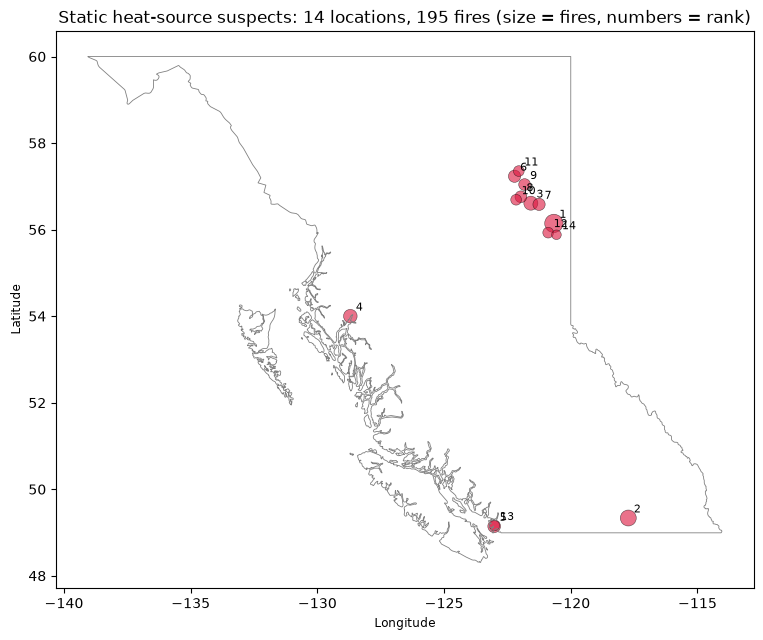

In [7]:
suspect_xy = small_xy[recurring]
pairs = cKDTree(suspect_xy).query_pairs(STATIC_RADIUS_KM * 1000, output_type="ndarray")
graph = coo_matrix((np.ones(len(pairs), dtype=bool), (pairs[:, 0], pairs[:, 1])),
                   shape=(len(suspects), len(suspects)))
location = connected_components(graph, directed=False)[1]
static_locations = (suspects.assign(location=location).groupby("location")
                    .agg(fires=("fire_id", "size"), years=("year", "nunique"), lat=("lat", "mean"),
                         lon=("lon", "mean"), detections=("n_detections", "sum"))
                    .sort_values(["fires", "detections"], ascending=False).reset_index(drop=True))
static_locations.index += 1
print(f"{len(static_locations)} static locations; top 15 by number of flagged fires:")
display(static_locations.head(15).round({"lat": 3, "lon": 3}))

bc = load_bc_boundary()
fig, ax = plt.subplots(figsize=(9, 8))
bc.boundary.plot(ax=ax, color="grey", linewidth=0.6)
ax.scatter(static_locations["lon"], static_locations["lat"], s=6 * static_locations["fires"],
           color="crimson", alpha=0.6, edgecolor="black", linewidth=0.4)
for rank, row in static_locations.head(15).iterrows():
    ax.annotate(str(rank), (row["lon"], row["lat"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set(title=f"Static heat-source suspects: {len(static_locations)} locations, {len(suspects)} fires "
             "(size = fires, numbers = rank)", xlabel="Longitude", ylabel="Latitude")
plt.show()

## 6. Weight
`weight = clip(n_cells_48h, 1, cap)`. The cap is the 95th percentile of `n_cells_48h` over 2019–2022 only,
so the 2023 test year does not influence it.

In [8]:
WEIGHT_CAP = float(np.percentile(ignitions.loc[ignitions["year"].isin(TRAIN_YEARS), "n_cells_48h"],
                                 WEIGHT_CAP_PERCENTILE))
ignitions["weight"] = ignitions["n_cells_48h"].clip(lower=1, upper=WEIGHT_CAP).astype(float)
print(f"WEIGHT_CAP = {WEIGHT_CAP:g} cells "
      f"({WEIGHT_CAP_PERCENTILE}th percentile of n_cells_48h, {TRAIN_YEARS[0]}-{TRAIN_YEARS[-1]})")
print(f"Fires at the cap: {(ignitions['n_cells_48h'] >= WEIGHT_CAP).sum():,} of {len(ignitions):,}")

WEIGHT_CAP = 16 cells (95th percentile of n_cells_48h, 2019-2022)
Fires at the cap: 476 of 7,227


## 7. Sanity checks

In [9]:
summary = ignitions.groupby("year").agg(
    fires=("fire_id", "size"), static_suspects=("static_suspect", "sum"),
    median_weight=("weight", "median"), max_weight=("weight", "max"),
    total_weight=("weight", "sum"), median_active_days=("active_days", "median"))
display(summary)

,fires,static_suspects,median_weight,max_weight,total_weight,median_active_days
year,,,,,,
2019,1421,31,2.0,16.0,5908.0,1.0
2020,954,31,2.0,16.0,3261.0,1.0
2021,1631,55,2.0,16.0,7108.0,1.0
2022,815,33,2.0,16.0,2645.0,1.0
2023,2406,45,2.0,16.0,10684.0,1.0


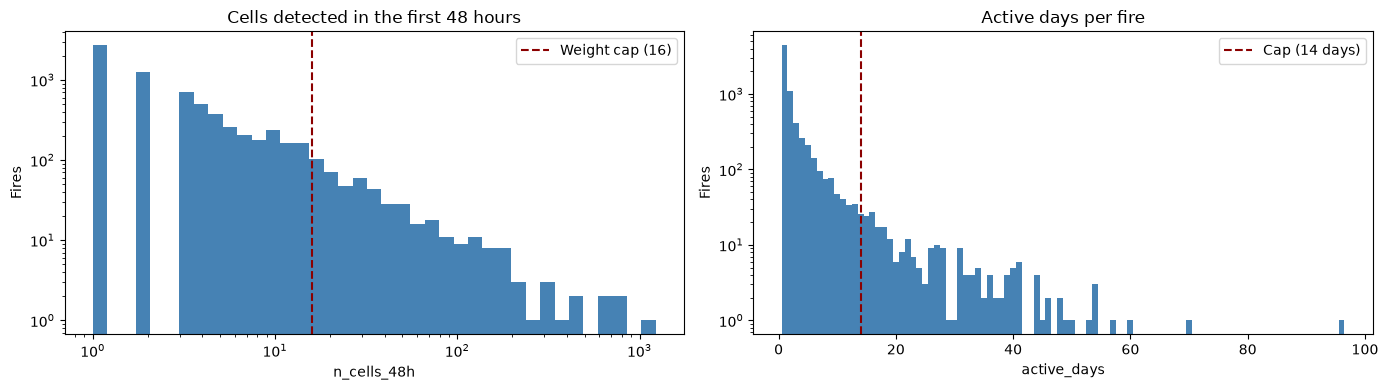

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(ignitions["n_cells_48h"], bins=np.logspace(0, np.log10(ignitions["n_cells_48h"].max()), 40),
             color="steelblue")
axes[0].axvline(WEIGHT_CAP, color="darkred", linestyle="--", label=f"Weight cap ({WEIGHT_CAP:g})")
axes[0].set(xscale="log", yscale="log", xlabel="n_cells_48h", ylabel="Fires", title="Cells detected in the first 48 hours")
axes[0].legend()
axes[1].hist(ignitions["active_days"], bins=np.arange(0.5, ignitions["active_days"].max() + 1.5, 1), color="steelblue")
axes[1].axvline(ACTIVE_DAYS_CAP, color="darkred", linestyle="--", label=f"Cap ({ACTIVE_DAYS_CAP} days)")
axes[1].set(yscale="log", xlabel="active_days", ylabel="Fires", title="Active days per fire")
axes[1].legend()
plt.tight_layout()
plt.show()

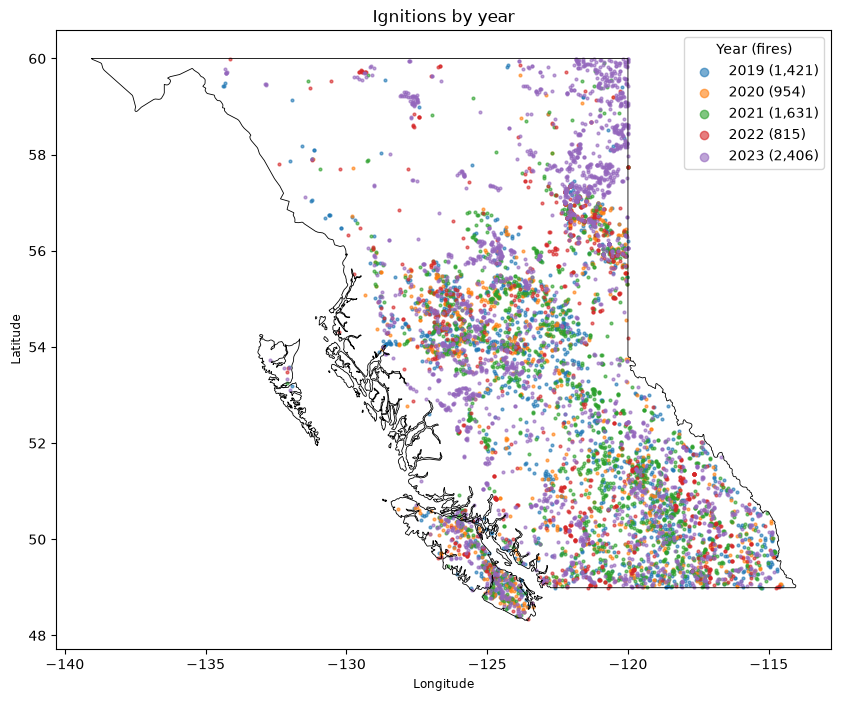

In [11]:
fig, ax = plt.subplots(figsize=(10, 9))
bc.boundary.plot(ax=ax, color="black", linewidth=0.6)
colors = plt.get_cmap("tab10")
for number, year in enumerate(YEARS):
    subset = ignitions[ignitions["year"] == year]
    ax.scatter(subset["lon"], subset["lat"], s=4, alpha=0.6, color=colors(number), label=f"{year} ({len(subset):,})")
ax.set(title="Ignitions by year", xlabel="Longitude", ylabel="Latitude")
ax.legend(markerscale=3, title="Year (fires)")
plt.show()

In [12]:
points = gpd.GeoSeries(gpd.points_from_xy(ignitions["lon"], ignitions["lat"]), crs="EPSG:4326")
inside = points.intersects(bc.geometry.iloc[0]).to_numpy()
checks = {
    "no missing values": not ignitions.isna().any().any(),
    "fire_id is unique": ignitions["fire_id"].is_unique,
    "all ignitions inside BC": bool(inside.all()),
    "first_date <= last_date": bool((ignitions["first_date"] <= ignitions["last_date"]).all()),
    "ignition on first_date": bool((ignitions["ignition_time_utc"].dt.tz_localize(None).dt.normalize()
                                    == ignitions["first_date"]).all()),
    "n_detections matches type-0 rows": int(ignitions["n_detections"].sum()) == sum(len(detections[y]) for y in YEARS),
}
for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}  {name}")
if not inside.all():
    print(f"{(~inside).sum()} ignitions fall outside the BC boundary:")
    display(ignitions.loc[~inside, ["fire_id", "lat", "lon", "n_detections", "extent_km"]])

PASS  no missing values
PASS  fire_id is unique
PASS  all ignitions inside BC
PASS  first_date <= last_date
PASS  ignition on first_date
PASS  n_detections matches type-0 rows


### Parameter sensitivity
Fire counts per year under a tighter and a looser link rule, next to the main one. Counts only.

In [13]:
sensitivity = pd.DataFrame({
    f"{link_km:g} km / {link_days} d": {year: len(np.unique(cluster(thinned[year], link_km, link_days)[0]))
                                        for year in YEARS}
    for link_km, link_days in SENSITIVITY}).rename_axis("year")
sensitivity.loc["total"] = sensitivity.sum()
display(sensitivity)

,1 km / 2 d,1.5 km / 3 d,3 km / 5 d
year,,,
2019,1919,1694,1421
2020,1218,1107,954
2021,3160,2322,1631
2022,1451,1102,815
2023,7500,4807,2406
total,15248,11032,7227


## 8. Save
All years and all columns, including flagged fires. The settings that shaped the table go to `ignitions_meta.json` for the export step.

In [14]:
ignitions.to_parquet(OUTPUT_PATH, engine="pyarrow", index=False)
print(f"Saved {len(ignitions):,} fires to {OUTPUT_PATH.relative_to(REPO_ROOT)}")
ignitions_meta = {
    "link_km": LINK_KM, "link_days": LINK_DAYS, "weight_cap": WEIGHT_CAP,
    "static_max_extent_km": STATIC_MAX_EXTENT_KM, "static_max_cells_48h": STATIC_MAX_CELLS_48H,
    "static_radius_km": STATIC_RADIUS_KM, "static_min_fires": STATIC_MIN_FIRES, "static_min_years": STATIC_MIN_YEARS,
}
META_PATH.write_text(json.dumps(ignitions_meta, indent=2), encoding="utf-8")
print(f"Saved {META_PATH.relative_to(REPO_ROOT)}: {ignitions_meta}")
print(ignitions.dtypes)

Saved 7,227 fires to data\processed\ignitions.parquet
Saved data\processed\ignitions_meta.json: {'link_km': 3.0, 'link_days': 5, 'weight_cap': 16.0, 'static_max_extent_km': 1, 'static_max_cells_48h': 2, 'static_radius_km': 1, 'static_min_fires': 8, 'static_min_years': 3}
fire_id                               str
year                                int64
ignition_time_utc     datetime64[us, UTC]
lat                               float64
lon                               float64
first_date                 datetime64[us]
last_date                  datetime64[us]
active_days                         int64
active_days_capped                  int64
n_detections                        int64
n_cells_48h                         int64
frp_sum_48h                       float64
extent_km                         float64
source                                str
static_suspect                       bool
weight                            float64
dtype: object
